In [132]:
import os
import sys
import json
import numpy as np
import matplotlib.pyplot as plt

from matplotlib.ticker import MaxNLocator

In [116]:
good_filename_lines = """
'inter-data/borsan-midi/287-42.mid...',
 'inter-data/borsan-midi/287-56.mid...',
 'inter-data/borsan-midi/273-8.mid...',
 'inter-data/borsan-midi/254-24.mid...',
 'inter-data/borsan-midi/254-18.mid...',
 'inter-data/borsan-midi/256-16--A3.mid...',
 'inter-data/borsan-midi/286-16.mid...',
 'inter-data/borsan-midi/256-6--A2.mid...',
 'inter-data/borsan-midi/252-142.mid...',
 'inter-data/borsan-midi/242-5.mid...',
 'inter-data/borsan-midi/286-138.mid...',
 'inter-data/borsan-midi/252-86.mid...',
 'inter-data/borsan-midi/252-92.mid...',
 'inter-data/borsan-midi/252-87.mid...',
 'inter-data/borsan-midi/252-78.mid...',
 'inter-data/borsan-midi/248-20.mid...',
 'inter-data/borsan-midi/252-44.mid...',
 'inter-data/borsan-midi/286-111.mid...',
 'inter-data/borsan-midi/286-105.mid...',
 'inter-data/borsan-midi/256-37c--A3.mid...',
 'inter-data/borsan-midi/256-6--A3.mid...',
 'inter-data/borsan-midi/286-17.mid...',
 'inter-data/borsan-midi/257-6--B.mid...',
 'inter-data/borsan-midi/273-9.mid...',
 'inter-data/borsan-midi/287-80.mid...',
 'inter-data/borsan-midi/287-57.mid...',
 'inter-data/borsan-midi/287-43.mid...',
 'inter-data/borsan-midi/287-55.mid...',
 'inter-data/borsan-midi/287-41.mid...',
 'inter-data/borsan-midi/254-27.mid...',
 'inter-data/borsan-midi/267-59--B.mid...',
 'inter-data/borsan-midi/267-24--B.mid...',
 'inter-data/borsan-midi/286-15.mid...',
 'inter-data/borsan-midi/286-107.mid...',
 'inter-data/borsan-midi/252-52.mid...',
 'inter-data/borsan-midi/252-46.mid...',
 'inter-data/borsan-midi/252-91.mid...',
 'inter-data/borsan-midi/252-85.mid...',
 'inter-data/borsan-midi/252-84.mid...',
 'inter-data/borsan-midi/286-3.mid...',
 'inter-data/borsan-midi/252-90.mid...',
 'inter-data/borsan-midi/252-47.mid...',
 'inter-data/borsan-midi/252-53.mid...',
 'inter-data/borsan-midi/286-106.mid...',
 'inter-data/borsan-midi/286-112.mid...',
 'inter-data/borsan-midi/286-28.mid...',
 'inter-data/borsan-midi/256-42--A3.mid...',
 'inter-data/borsan-midi/267-12--B.mid...',
 'inter-data/borsan-midi/287-50.mid...',
 'inter-data/borsan-midi/287-44.mid...',
 'inter-data/borsan-midi/287-78.mid...',
 'inter-data/borsan-midi/267-34--B.mid...',
 'inter-data/borsan-midi/244-5.mid...',
 'inter-data/borsan-midi/252-144.mid...',
 'inter-data/borsan-midi/267-26--B.mid...',
 'inter-data/borsan-midi/286-116.mid...',
 'inter-data/borsan-midi/267-45--B.mid...',
 'inter-data/borsan-midi/256-7--A1.mid...',
 'inter-data/borsan-midi/252-94.mid...',
 'inter-data/borsan-midi/252-80.mid...',
 'inter-data/borsan-midi/256-43--A3.mid...',
 'inter-data/borsan-midi/267-10--B.mid...',
 'inter-data/borsan-midi/286-117.mid...',
 'inter-data/borsan-midi/277-17.mid...',
 'inter-data/borsan-midi/252-34--b.mid...',
 'inter-data/borsan-midi/252-151.mid...',
 'inter-data/borsan-midi/252-145.mid...',
 'inter-data/borsan-midi/244-4.mid...',
 'inter-data/borsan-midi/279-2--B.mid...',
 'inter-data/borsan-midi/256-21--A3.mid...',
 'inter-data/borsan-midi/256-31--A3.mid...',
 'inter-data/borsan-midi/267-61--B.mid...',
 'inter-data/borsan-midi/248-9.mid...',
 'inter-data/borsan-midi/287-45.mid...',
 'inter-data/borsan-midi/287-51.mid...',
 'inter-data/borsan-midi/287-53.mid...',
 'inter-data/borsan-midi/259-3.mid...',
 'inter-data/borsan-midi/254-21.mid...',
 'inter-data/borsan-midi/239-1--A.mid...',
 'inter-data/borsan-midi/244-6.mid...',
 'inter-data/borsan-midi/277-15.mid...',
 'inter-data/borsan-midi/286-129.mid...',
 'inter-data/borsan-midi/256-7--A2.mid...',
 'inter-data/borsan-midi/252-54.mid...',
 'inter-data/borsan-midi/253-8.mid...',
 'inter-data/borsan-midi/252-83.mid...',
 'inter-data/borsan-midi/286-4.mid...',
 'inter-data/borsan-midi/252-97.mid...',
 'inter-data/borsan-midi/252-96.mid...',
 'inter-data/borsan-midi/253-9.mid...',
 'inter-data/borsan-midi/256-7--A3.mid...',
 'inter-data/borsan-midi/248-19.mid...',
 'inter-data/borsan-midi/256-37b--A3.mid...',
 'inter-data/borsan-midi/252-69.mid...',
 'inter-data/borsan-midi/286-114.mid...',
 'inter-data/borsan-midi/256-38--A3.mid...',
 'inter-data/borsan-midi/256-28--A3.mid...',
 'inter-data/borsan-midi/279-18--B.mid...',
 'inter-data/borsan-midi/286-100.mid...',
 'inter-data/borsan-midi/286-128.mid...',
 'inter-data/borsan-midi/277-8.mid...',
 'inter-data/borsan-midi/252-146.mid...',
 'inter-data/borsan-midi/257-8--B.mid...',
 'inter-data/borsan-midi/254-20.mid...',
 'inter-data/borsan-midi/259-2.mid...',
 'inter-data/borsan-midi/287-46.mid...',
 'inter-data/borsan-midi/279-6--B.mid...',
 'inter-data/borsan-midi/287-21.mid...',
 'inter-data/borsan-midi/287-2.mid...',
 'inter-data/borsan-midi/243-6.mid...',
 'inter-data/borsan-midi/286-75.mid...',
 'inter-data/borsan-midi/252-135.mid...',
 'inter-data/borsan-midi/252-121.mid...',
 'inter-data/borsan-midi/283-6.mid...',
 'inter-data/borsan-midi/286-167.mid...',
 'inter-data/borsan-midi/252-26.mid...',
 'inter-data/borsan-midi/252-32.mid...',
 'inter-data/borsan-midi/254-8.mid...',
 'inter-data/borsan-midi/254-9.mid...',
 'inter-data/borsan-midi/252-27.mid...',
 'inter-data/borsan-midi/286-166.mid...',
 'inter-data/borsan-midi/252-120.mid...',
 'inter-data/borsan-midi/286-48.mid...',
 'inter-data/borsan-midi/252-134.mid...',
 'inter-data/borsan-midi/243-7.mid...',
 'inter-data/borsan-midi/287-36.mid...',
 'inter-data/borsan-midi/287-22.mid...',
 'inter-data/borsan-midi/287-1.mid...',
 'inter-data/borsan-midi/258-10--C.mid...',
 'inter-data/borsan-midi/256-5--A2.mid...',
 'inter-data/borsan-midi/285-3.mid...',
 'inter-data/borsan-midi/243-5.mid...',
 'inter-data/borsan-midi/286-76.mid...',
 'inter-data/borsan-midi/286-89.mid...',
 'inter-data/borsan-midi/252-31.mid...',
 'inter-data/borsan-midi/252-25.mid...',
 'inter-data/borsan-midi/256-48--A3.mid...',
 'inter-data/borsan-midi/239-9--A.mid...',
 'inter-data/borsan-midi/286-159.mid...',
 'inter-data/borsan-midi/286-88.mid...',
 'inter-data/borsan-midi/286-165.mid...',
 'inter-data/borsan-midi/286-77.mid...',
 'inter-data/borsan-midi/286-63.mid...',
 'inter-data/borsan-midi/267-7--B.mid...',
 'inter-data/borsan-midi/243-4.mid...',
 'inter-data/borsan-midi/256-5--A3.mid...',
 'inter-data/borsan-midi/239-5--A.mid...',
 'inter-data/borsan-midi/287-23.mid...',
 'inter-data/borsan-midi/256-4--A2.mid...',
 'inter-data/borsan-midi/252-127.mid...',
 'inter-data/borsan-midi/252-133.mid...',
 'inter-data/borsan-midi/258-12--C.mid...',
 'inter-data/borsan-midi/286-149.mid...',
 'inter-data/borsan-midi/263-5.mid...',
 'inter-data/borsan-midi/252-34.mid...',
 'inter-data/borsan-midi/252-20.mid...',
 'inter-data/borsan-midi/247-5.mid...',
 'inter-data/borsan-midi/239-7--A.mid...',
 'inter-data/borsan-midi/252-21.mid...',
 'inter-data/borsan-midi/252-35.mid...',
 'inter-data/borsan-midi/286-160.mid...',
 'inter-data/borsan-midi/286-72.mid...',
 'inter-data/borsan-midi/258-5--C.mid...',
 'inter-data/borsan-midi/286-66.mid...',
 'inter-data/borsan-midi/252-132.mid...',
 'inter-data/borsan-midi/252-126.mid...',
 'inter-data/borsan-midi/265-2.mid...',
 'inter-data/borsan-midi/258-9--C.mid...',
 'inter-data/borsan-midi/256-37a--A3.mid...',
 'inter-data/borsan-midi/241-3.mid...',
 'inter-data/borsan-midi/287-24.mid...',
 'inter-data/borsan-midi/287-30.mid...',
 'inter-data/borsan-midi/252-130.mid...',
 'inter-data/borsan-midi/286-176.mid...',
 'inter-data/borsan-midi/279-4--B.mid...',
 'inter-data/borsan-midi/247-7.mid...',
 'inter-data/borsan-midi/247-6.mid...',
 'inter-data/borsan-midi/252-36.mid...',
 'inter-data/borsan-midi/267-51--B.mid...',
 'inter-data/borsan-midi/286-177.mid...',
 'inter-data/borsan-midi/286-163.mid...',
 'inter-data/borsan-midi/267-32--B.mid...',
 'inter-data/borsan-midi/252-119.mid...',
 'inter-data/borsan-midi/286-71.mid...',
 'inter-data/borsan-midi/252-125.mid...',
 'inter-data/borsan-midi/252-131.mid...',
 'inter-data/borsan-midi/243-2.mid...',
 'inter-data/borsan-midi/256-11--A1.mid...',
 'inter-data/borsan-midi/287-14.mid...',
 'inter-data/borsan-midi/256-8--A3.mid...',
 'inter-data/borsan-midi/267-62--B.mid...',
 'inter-data/borsan-midi/277-6--B.mid...',
 'inter-data/borsan-midi/267-13--B.mid...',
 'inter-data/borsan-midi/286-68.mid...',
 'inter-data/borsan-midi/286-97.mid...',
 'inter-data/borsan-midi/241-5--C.mid...',
 'inter-data/borsan-midi/267-58--B.mid...',
 'inter-data/borsan-midi/286-82.mid...',
 'inter-data/borsan-midi/286-69.mid...',
 'inter-data/borsan-midi/267-46--B.mid...',
 'inter-data/borsan-midi/286-41.mid...',
 'inter-data/borsan-midi/286-55.mid...',
 'inter-data/borsan-midi/252-129.mid...',
 'inter-data/borsan-midi/286-184.mid...',
 'inter-data/borsan-midi/267-37--B.mid...',
 'inter-data/borsan-midi/274-5.mid...',
 'inter-data/borsan-midi/267-54--B.mid...',
 'inter-data/borsan-midi/287-29.mid...',
 'inter-data/borsan-midi/261-4--B.mid...',
 'inter-data/borsan-midi/252-103.mid...',
 'inter-data/borsan-midi/252-117.mid...',
 'inter-data/borsan-midi/286-80.mid...',
 'inter-data/borsan-midi/286-145.mid...',
 'inter-data/borsan-midi/286-94.mid...',
 'inter-data/borsan-midi/252-38.mid...',
 'inter-data/borsan-midi/256-1--A2.mid...',
 'inter-data/borsan-midi/256-63--A3.mid...',
 'inter-data/borsan-midi/252-39.mid...',
 'inter-data/borsan-midi/286-95.mid...',
 'inter-data/borsan-midi/286-81.mid...',
 'inter-data/borsan-midi/270-2.mid...',
 'inter-data/borsan-midi/252-102.mid...',
 'inter-data/borsan-midi/286-56.mid...',
 'inter-data/borsan-midi/256-8--A1.mid...',
 'inter-data/borsan-midi/257-5--B.mid...',
 'inter-data/borsan-midi/252-106.mid...',
 'inter-data/borsan-midi/252-112.mid...',
 'inter-data/borsan-midi/258-15--C.mid...',
 'inter-data/borsan-midi/286-46.mid...',
 'inter-data/borsan-midi/286-52.mid...',
 'inter-data/borsan-midi/286-168.mid...',
 'inter-data/borsan-midi/286-85.mid...',
 'inter-data/borsan-midi/286-140.mid...',
 'inter-data/borsan-midi/237-4.mid...',
 'inter-data/borsan-midi/254-7.mid...',
 'inter-data/borsan-midi/254-6.mid...',
 'inter-data/borsan-midi/237-5.mid...',
 'inter-data/borsan-midi/252-28.mid...',
 'inter-data/borsan-midi/286-90.mid...',
 'inter-data/borsan-midi/256-62--A3.mid...',
 'inter-data/borsan-midi/286-155.mid...',
 'inter-data/borsan-midi/286-84.mid...',
 'inter-data/borsan-midi/286-53.mid...',
 'inter-data/borsan-midi/286-47.mid...',
 'inter-data/borsan-midi/252-113.mid...',
 'inter-data/borsan-midi/256-10--A3.mid...',
 'inter-data/borsan-midi/274-3.mid...',
 'inter-data/borsan-midi/287-39.mid...',
 'inter-data/borsan-midi/256-10--A1.mid...',
 'inter-data/borsan-midi/256-36--A3.mid...',
 'inter-data/borsan-midi/267-11--B.mid...',
 'inter-data/borsan-midi/286-79.mid...',
 'inter-data/borsan-midi/252-105.mid...',
 'inter-data/borsan-midi/286-180.mid...',
 'inter-data/borsan-midi/286-51.mid...',
 'inter-data/borsan-midi/252-139.mid...',
 'inter-data/borsan-midi/256-44--A3.mid...',
 'inter-data/borsan-midi/267-60--B.mid...',
 'inter-data/borsan-midi/256-54--A3.mid...',
 'inter-data/borsan-midi/286-143.mid...',
 'inter-data/borsan-midi/286-92.mid...',
 'inter-data/borsan-midi/270-5.mid...',
 'inter-data/borsan-midi/279-3--B.mid...',
 'inter-data/borsan-midi/256-19--A3.mid...',
 'inter-data/borsan-midi/270-4.mid...',
 'inter-data/borsan-midi/286-87.mid...',
 'inter-data/borsan-midi/267-48--B.mid...',
 'inter-data/borsan-midi/286-181.mid...',
 'inter-data/borsan-midi/286-78.mid...',
 'inter-data/borsan-midi/252-110.mid...',
 'inter-data/borsan-midi/267-39--B.mid...',
 'inter-data/borsan-midi/287-38.mid...',
 'inter-data/borsan-midi/287-77.mid...',
 'inter-data/borsan-midi/239-8--A.mid...',
 'inter-data/borsan-midi/286-37.mid...',
 'inter-data/borsan-midi/286-23.mid...',
 'inter-data/borsan-midi/286-125.mid...',
 'inter-data/borsan-midi/277-5.mid...',
 'inter-data/borsan-midi/286-131.mid...',
 'inter-data/borsan-midi/277-19.mid...',
 'inter-data/borsan-midi/252-70.mid...',
 'inter-data/borsan-midi/252-59.mid...',
 'inter-data/borsan-midi/258-11--C.mid...',
 'inter-data/borsan-midi/252-71.mid...',
 'inter-data/borsan-midi/252-65.mid...',
 'inter-data/borsan-midi/261-1--Bb.mid...',
 'inter-data/borsan-midi/286-130.mid...',
 'inter-data/borsan-midi/277-4.mid...',
 'inter-data/borsan-midi/286-124.mid...',
 'inter-data/borsan-midi/286-22.mid...',
 'inter-data/borsan-midi/286-36.mid...',
 'inter-data/borsan-midi/254-10.mid...',
 'inter-data/borsan-midi/287-76.mid...',
 'inter-data/borsan-midi/287-62.mid...',
 'inter-data/borsan-midi/256-2--A2.mid...',
 'inter-data/borsan-midi/248-6.mid...',
 'inter-data/borsan-midi/256-60--A3.mid...',
 'inter-data/borsan-midi/239-10--A.mid...',
 'inter-data/borsan-midi/287-74.mid...',
 'inter-data/borsan-midi/256-56--A3.mid...',
 'inter-data/borsan-midi/255-1.mid...',
 'inter-data/borsan-midi/267-23--B.mid...',
 'inter-data/borsan-midi/286-34.mid...',
 'inter-data/borsan-midi/267-52--B.mid...',
 'inter-data/borsan-midi/252-73.mid...',
 'inter-data/borsan-midi/252-67.mid...',
 'inter-data/borsan-midi/248-17.mid...',
 'inter-data/borsan-midi/267-31--B.mid...',
 'inter-data/borsan-midi/256-24--A3.mid...',
 'inter-data/borsan-midi/256-12--A1.mid...',
 'inter-data/borsan-midi/252-98.mid...',
 'inter-data/borsan-midi/252-99.mid...',
 'inter-data/borsan-midi/252-72.mid...',
 'inter-data/borsan-midi/286-127.mid...',
 'inter-data/borsan-midi/286-133.mid...',
 'inter-data/borsan-midi/261-1--Ba.mid...',
 'inter-data/borsan-midi/279-7--B.mid...',
 'inter-data/borsan-midi/287-75.mid...',
 'inter-data/borsan-midi/287-49.mid...',
 'inter-data/borsan-midi/256-2--A1.mid...',
 'inter-data/borsan-midi/287-71.mid...',
 'inter-data/borsan-midi/287-65.mid...',
 'inter-data/borsan-midi/248-1.mid...',
 'inter-data/borsan-midi/287-59.mid...',
 'inter-data/borsan-midi/273-7.mid...',
 'inter-data/borsan-midi/286-25.mid...',
 'inter-data/borsan-midi/277-3.mid...',
 'inter-data/borsan-midi/256-25--A3.mid...',
 'inter-data/borsan-midi/286-123.mid...',
 'inter-data/borsan-midi/256-35--A3.mid...',
 'inter-data/borsan-midi/248-12.mid...',
 'inter-data/borsan-midi/252-76.mid...',
 'inter-data/borsan-midi/252-89.mid...',
 'inter-data/borsan-midi/240-8.mid...',
 'inter-data/borsan-midi/275-1.mid...',
 'inter-data/borsan-midi/252-88.mid...',
 'inter-data/borsan-midi/252-63.mid...',
 'inter-data/borsan-midi/252-77.mid...',
 'inter-data/borsan-midi/248-13.mid...',
 'inter-data/borsan-midi/286-122.mid...',
 'inter-data/borsan-midi/286-136.mid...',
 'inter-data/borsan-midi/277-2.mid...',
 'inter-data/borsan-midi/279-9--B.mid...',
 'inter-data/borsan-midi/286-30.mid...',
 'inter-data/borsan-midi/286-24.mid...',
 'inter-data/borsan-midi/254-16.mid...',
 'inter-data/borsan-midi/279-5--B.mid...',
 'inter-data/borsan-midi/273-6.mid...',
 'inter-data/borsan-midi/287-58.mid...',
 'inter-data/borsan-midi/287-64.mid...',
 'inter-data/borsan-midi/287-66.mid...',
 'inter-data/borsan-midi/287-72.mid...',
 'inter-data/borsan-midi/267-8--B.mid...',
 'inter-data/borsan-midi/286-32.mid...',
 'inter-data/borsan-midi/286-134.mid...',
 'inter-data/borsan-midi/252-61.mid...',
 'inter-data/borsan-midi/252-75.mid...',
 'inter-data/borsan-midi/258-8--C.mid...',
 'inter-data/borsan-midi/253-1.mid...',
 'inter-data/borsan-midi/252-60.mid...',
 'inter-data/borsan-midi/286-109.mid...',
 'inter-data/borsan-midi/286-33.mid...',
 'inter-data/borsan-midi/279-13--B.mid...',
 'inter-data/borsan-midi/256-61--A3.mid...',
 'inter-data/borsan-midi/256-3--A2.mid...',
 'inter-data/borsan-midi/287-73.mid...']

"""

In [125]:
regionwise_path = "inter-data/borsan-midi-regionwise-no-dupes"

In [126]:
good_filenames = good_filename_lines.split()

In [127]:
good_song_ids = set()
for fname in good_filenames:
    song_id = fname[ fname.rfind("/")+1:fname.find( "." )]
    good_song_ids.add( song_id )

In [128]:
for directory in os.listdir( regionwise_path ):
    if os.path.isdir( f"{regionwise_path}/{directory}" ):
        print( f"Processing regional folder {regionwise_path}/{directory}" )
        
        for song_path in os.listdir( f"{regionwise_path}/{directory}" ):
            song_id = song_path[ song_path.rfind("/")+1:song_path.find( "." )]
            
            if song_id not in good_song_ids:
                print( f"Removing {song_id} because its MIDI cannot be read by IDyOM.")
                !rm {regionwise_path}/{directory}/{song_path}      
        
        print()

Processing regional folder inter-data/borsan-midi-regionwise-no-dupes/Dolenjska

Processing regional folder inter-data/borsan-midi-regionwise-no-dupes/Gorski_Kotar_HR

Processing regional folder inter-data/borsan-midi-regionwise-no-dupes/Štajerska_
Removing 287-28 because its MIDI cannot be read by IDyOM.

Processing regional folder inter-data/borsan-midi-regionwise-no-dupes/Primorska

Processing regional folder inter-data/borsan-midi-regionwise-no-dupes/Primorska_IT

Processing regional folder inter-data/borsan-midi-regionwise-no-dupes/Gorenjska
Removing 256-14--A3 because its MIDI cannot be read by IDyOM.
Removing 237-3 because its MIDI cannot be read by IDyOM.
Removing 272-6 because its MIDI cannot be read by IDyOM.
Removing 251-3 because its MIDI cannot be read by IDyOM.

Processing regional folder inter-data/borsan-midi-regionwise-no-dupes/Medžimurje_HR
Removing 266-1--A because its MIDI cannot be read by IDyOM.

Processing regional folder inter-data/borsan-midi-regionwise-no-du

In [129]:
region_song_counts = {}
for item in os.listdir( regionwise_path ):
    if os.path.isdir( f"{regionwise_path}/{item}" ):
        region_song_counts[ item ] = len( os.listdir( f"{regionwise_path}/{item}" ) )

In [130]:
region_song_counts = [ item for item in region_song_counts.items() ]
region_song_counts = sorted( region_song_counts, key=lambda tup: -tup[ 1 ] )

In [131]:
region_song_counts

[('Štajerska', 18),
 ('Gorenjska', 16),
 ('Dolenjska', 11),
 ('Prekmurje', 9),
 ('Primorska', 8),
 ('Notranjska', 7),
 ('Porabje_HU', 7),
 ('Primorska_IT', 4),
 ('Koroška_AT', 3),
 ('Bela_krajina', 3),
 ('Benečija_IT', 2),
 ('Gorski_Kotar_HR', 1),
 ('Medžimurje_HR', 1),
 ('Tropeti_or_Čabar_HR', 1),
 ('Apátistvanfalva_HU', 1),
 ('Alsószölnök_HU', 1),
 ('_', 1),
 ('Kranjsko', 1),
 ('Vivodina_HR', 1),
 ('Rezija_IT', 1),
 ('Unknown', 1),
 ('Štajerska_', 0)]

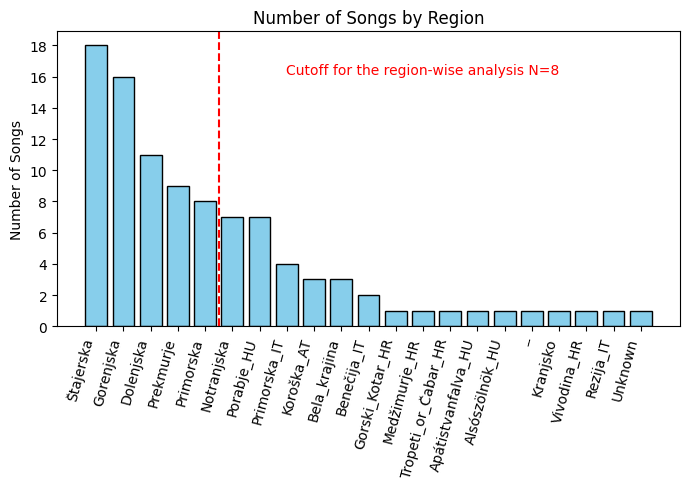

In [144]:
# Filter out regions with 0 songs
region_song_counts = [item for item in region_song_counts if item[1] > 0]

# Split into names and counts
regions, counts = zip(*region_song_counts)

# Plot
plt.figure(figsize=(7, 5))
bars = plt.bar(regions, counts, color='skyblue', edgecolor='black')
plt.xticks(rotation=75, ha='right')
plt.ylabel("Number of Songs")
plt.title("Number of Songs by Region")

# Add vertical line after "Primorska" (5th item, so index 5)
cutoff_index = 5  # this is the index *after* "Primorska"
plt.axvline(x=cutoff_index - 0.5, color='red', linestyle='--')

# Make y-axis integer only
plt.gca().yaxis.set_major_locator(MaxNLocator(integer=True))

# Add label
plt.text(cutoff_index + 12, max(counts) - 2, "Cutoff for the region-wise analysis N=8", 
         color='red', rotation=0, verticalalignment='bottom', horizontalalignment='right')

plt.tight_layout()
plt.show()

In [134]:
!mkdir inter-data/borsan-midi-clean-no-dupes

In [135]:
for directory in os.listdir( regionwise_path ):
    if os.path.isdir( f"{regionwise_path}/{directory}" ):
        print( f"{regionwise_path}/{directory}" )
        
        for song_path in os.listdir( f"{regionwise_path}/{directory}" ):
            !cp {regionwise_path}/{directory}/{song_path} inter-data/borsan-midi-clean-no-dupes/{song_path} 

inter-data/borsan-midi-regionwise-no-dupes/Dolenjska
inter-data/borsan-midi-regionwise-no-dupes/Gorski_Kotar_HR
inter-data/borsan-midi-regionwise-no-dupes/Štajerska_
inter-data/borsan-midi-regionwise-no-dupes/Primorska
inter-data/borsan-midi-regionwise-no-dupes/Primorska_IT
inter-data/borsan-midi-regionwise-no-dupes/Gorenjska
inter-data/borsan-midi-regionwise-no-dupes/Medžimurje_HR
inter-data/borsan-midi-regionwise-no-dupes/Tropeti_or_Čabar_HR
inter-data/borsan-midi-regionwise-no-dupes/Apátistvanfalva_HU
inter-data/borsan-midi-regionwise-no-dupes/Notranjska
inter-data/borsan-midi-regionwise-no-dupes/Alsószölnök_HU
inter-data/borsan-midi-regionwise-no-dupes/Koroška_AT
inter-data/borsan-midi-regionwise-no-dupes/_
inter-data/borsan-midi-regionwise-no-dupes/Kranjsko
inter-data/borsan-midi-regionwise-no-dupes/Vivodina_HR
inter-data/borsan-midi-regionwise-no-dupes/Bela_krajina
inter-data/borsan-midi-regionwise-no-dupes/Porabje_HU
inter-data/borsan-midi-regionwise-no-dupes/Rezija_IT
i